<a href="https://colab.research.google.com/github/DosSantos1301/resumo-do-lab/blob/main/Projeto_DDos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import pandas as pd
from datetime import datetime, timedelta

# Função para gerar logs simulados
def gerar_logs(n=100):
  logs = []
  inicio = datetime.now()
  for i in range (n):
    ip = f"192.168.1.{random.randint(1, 255)}" # IP fictício
    timestamp = inicio + timedelta(minutes=random.randint(0, 60))
    acao = random.choice(["login_sucesso", "login_falha"])
    logs.append([timestamp, ip, acao])
  return pd.DataFrame(logs, columns=["timestamp", "ip", "acao"])

#gerar 100 logs
dados = gerar_logs(n=100)
print(dados.head())

# Função para gerar logs simulados
def gerar_logs(n=100):
  logs = []
  inicio = datetime.now()
  for i in range (n):
    ip = f"192.168.1.{random.randint(1, 255)}" # IP fictício
    timestamp = inicio + timedelta(minutes=random.randint(0, 60))
    acao = random.choice(["login_sucesso", "login_falha"])
    logs.append([timestamp, ip, acao])
  return pd.DataFrame(logs, columns=["timestamp", "ip", "acao"])

#gerar 100 logs
dados = gerar_logs(n=100)
print(dados.head())

                   timestamp             ip           acao
0 2025-04-07 22:08:14.808189  192.168.1.236  login_sucesso
1 2025-04-07 21:51:14.808189   192.168.1.55  login_sucesso
2 2025-04-07 21:22:14.808189   192.168.1.24    login_falha
3 2025-04-07 21:46:14.808189  192.168.1.150  login_sucesso
4 2025-04-07 21:28:14.808189   192.168.1.53  login_sucesso
                   timestamp             ip           acao
0 2025-04-07 22:13:14.833083  192.168.1.131    login_falha
1 2025-04-07 21:25:14.833083   192.168.1.88  login_sucesso
2 2025-04-07 21:59:14.833083  192.168.1.188    login_falha
3 2025-04-07 21:33:14.833083   192.168.1.72  login_sucesso
4 2025-04-07 22:07:14.833083  192.168.1.155  login_sucesso


In [ ]:
# Simular um ataque de força bruta
ataque = []
inicio = datetime.now()  # Mesma referência de tempo usada antes
for i in range(20):  # 20 tentativas rápidas
    timestamp = inicio + timedelta(minutes=5 + i/10)  # Em 5 minutos
    ataque.append([timestamp, "192.168.1.100", "login_falha"])
# Adicionar o ataque ao conjunto de dados
dados = pd.concat([dados, pd.DataFrame(ataque, columns=["timestamp", "ip", "acao"])])
# Mostrar os últimos 5 registros para confirmar que o ataque foi adicionado
print(dados.tail())


                    timestamp             ip         acao
15 2025-04-07 15:51:06.839491  192.168.1.100  login_falha
16 2025-04-07 15:51:12.839491  192.168.1.100  login_falha
17 2025-04-07 15:51:18.839491  192.168.1.100  login_falha
18 2025-04-07 15:51:24.839491  192.168.1.100  login_falha
19 2025-04-07 15:51:30.839491  192.168.1.100  login_falha


In [ ]:
# Converter a coluna timestamp para o formato datetime
dados["timestamp"] = pd.to_datetime(dados["timestamp"])

# Definir o timestamp como índice do DataFrame
dados.set_index("timestamp", inplace=True)

# Agrupar por IP e contar tentativas em intervalos de 1 minuto
tentativas_por_ip = dados.groupby("ip").resample("1T").size().unstack(fill_value=0)

# Mostrar o resultado
print(tentativas_por_ip)


timestamp      2025-04-07 15:44:00  2025-04-07 15:45:00  2025-04-07 15:46:00  \
ip                                                                             
192.168.1.10                     0                    0                    0   
192.168.1.100                    0                    0                    0   
192.168.1.103                    0                    0                    0   
192.168.1.105                    0                    0                    0   
192.168.1.109                    0                    0                    0   
...                            ...                  ...                  ...   
192.168.1.84                     0                    0                    0   
192.168.1.86                     0                    0                    0   
192.168.1.91                     0                    0                    0   
192.168.1.94                     0                    0                    0   
192.168.1.96                     0      

<ipython-input-17-1aa0d62cafae>:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  tentativas_por_ip = dados.groupby("ip").resample("1T").size().unstack(fill_value=0)


In [ ]:
from sklearn.ensemble import IsolationForest

# Treinar o modelo Isolation Forest
modelo = IsolationForest(contamination=0.1, random_state=42)  # 10% de anomalias esperadas
predicoes = modelo.fit_predict(tentativas_por_ip)

# Identificar anomalias (predicoes = -1 significa anomalia)
anomalias = tentativas_por_ip[predicoes == -1]
print("IPs suspeitos (anomalias):")
print(anomalias.index.tolist())


IPs suspeitos (anomalias):
['192.168.1.100', '192.168.1.103', '192.168.1.151', '192.168.1.152', '192.168.1.171', '192.168.1.211', '192.168.1.232', '192.168.1.28', '192.168.1.84']


<ipython-input-19-93daf9fb99d1>:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


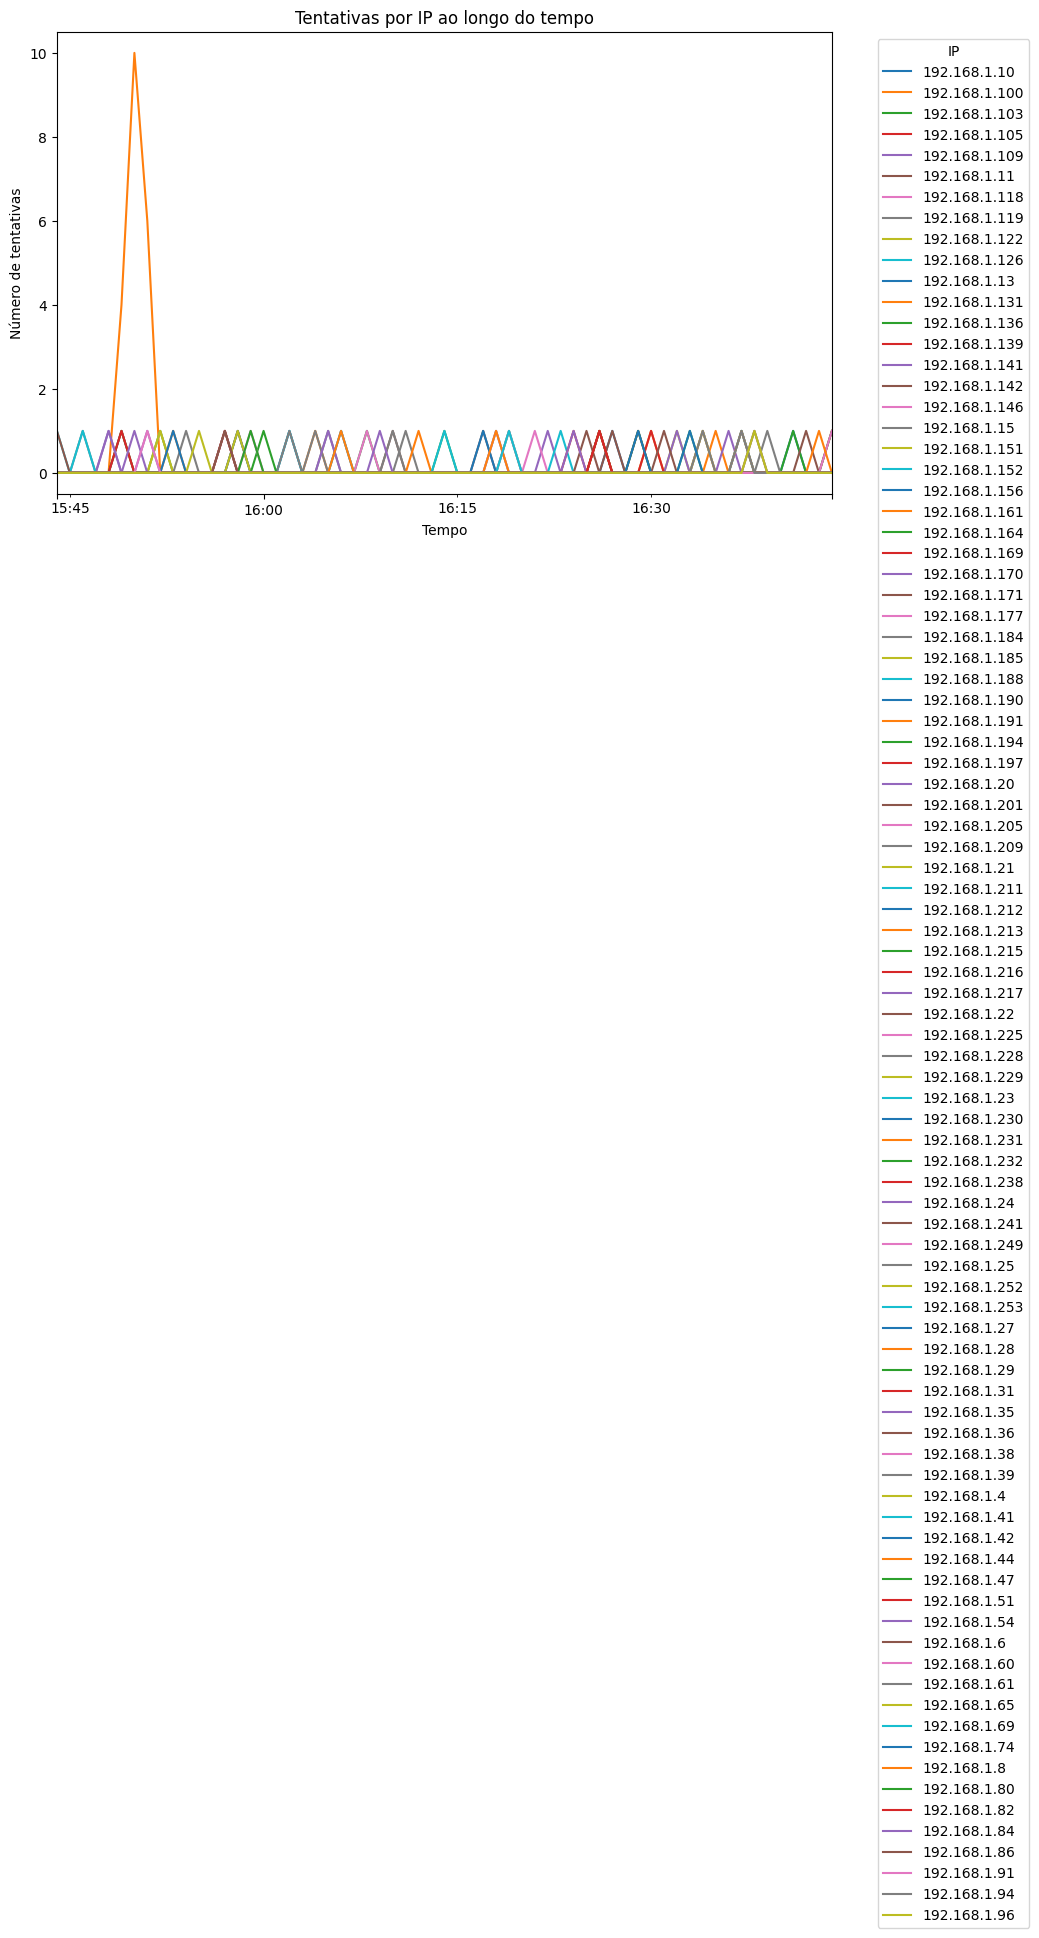

In [ ]:
import matplotlib.pyplot as plt

# Plotar as tentativas por IP ao longo do tempo
tentativas_por_ip.T.plot(figsize=(10, 6))
plt.title("Tentativas por IP ao longo do tempo")
plt.xlabel("Tempo")
plt.ylabel("Número de tentativas")
plt.legend(title="IP", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
# Simular um ataque distribuído (DDoS simulado)
ataque_ddos = []
inicio = datetime.now()  # Mesma referência de tempo
ips_ddos = [f"192.168.2.{i}" for i in range(1, 6)]  # 5 IPs diferentes: 192.168.2.1 a 192.168.2.5
for ip in ips_ddos:
    for i in range(10):  # Cada IP faz 10 tentativas
            timestamp = inicio + timedelta(minutes=10 + i/5)  # Em 3 minutos
            ataque_ddos.append([timestamp, ip, "login_falha"])

# Adicionar o ataque ao conjunto de dados
dados = pd.concat([dados, pd.DataFrame(ataque_ddos, columns=["timestamp", "ip", "acao"])])
print("Últimos 5 registros após adicionar o ataque DDoS:")
print(dados.tail())

Últimos 5 registros após adicionar o ataque DDoS:
             ip         acao                  timestamp
45  192.168.2.5  login_falha 2025-04-07 16:00:22.664635
46  192.168.2.5  login_falha 2025-04-07 16:00:34.664635
47  192.168.2.5  login_falha 2025-04-07 16:00:46.664635
48  192.168.2.5  login_falha 2025-04-07 16:00:58.664635
49  192.168.2.5  login_falha 2025-04-07 16:01:10.664635


In [ ]:
# Simular um ataque lento e prolongado (Slowloris simulado)
ataque_lento = []
ip_lento = "192.168.3.1"  # IP do ataque lento
for i in range(30):  # 30 tentativas ao longo de 30 minutos
    timestamp = inicio + timedelta(minutes=20 + i)  # 1 tentativa por minuto
    ataque_lento.append([timestamp, ip_lento, "login_falha"])

# Adicionar o ataque ao conjunto de dados
dados = pd.concat([dados, pd.DataFrame(ataque_lento, columns=["timestamp", "ip", "acao"])])
print("Últimos 5 registros após adicionar o ataque lento:")
print(dados.tail())


Últimos 5 registros após adicionar o ataque lento:
             ip         acao                  timestamp
25  192.168.3.1  login_falha 2025-04-07 16:34:22.664635
26  192.168.3.1  login_falha 2025-04-07 16:35:22.664635
27  192.168.3.1  login_falha 2025-04-07 16:36:22.664635
28  192.168.3.1  login_falha 2025-04-07 16:37:22.664635
29  192.168.3.1  login_falha 2025-04-07 16:38:22.664635


In [ ]:
# Verificar se há valores nulos na coluna timestamp
print("Valores nulos na coluna timestamp antes da conversão:")
print(dados["timestamp"].isna().sum())

# Converter a coluna timestamp para o formato datetime
dados["timestamp"] = pd.to_datetime(dados["timestamp"])

# Remover linhas com valores nulos na coluna timestamp
dados = dados.dropna(subset=["timestamp"])

# Verificar novamente após remover nulos
print("Valores nulos na coluna timestamp após remover nulos:")
print(dados["timestamp"].isna().sum())

# Definir o timestamp como índice do DataFrame
dados.set_index("timestamp", inplace=True)

# Agrupar por IP e contar tentativas em intervalos de 1 minuto
tentativas_por_ip = dados.groupby("ip").resample("1T").size().unstack(fill_value=0)

# Mostrar o resultado
print(tentativas_por_ip)


Valores nulos na coluna timestamp antes da conversão:


KeyError: 'timestamp'